# 🔋 Simulasi Extended Kalman Filter (EKF) Menggunakan Parameter `.mat`

**Tujuan:** Mengimplementasikan algoritma *Extended Kalman Filter* (EKF) untuk estimasi State of Charge (SOC) baterai LiFePO4. Model matematika (OCV dan ECM 1RC) tidak lagi dihitung ulang dari nol, melainkan diimpor langsung dari model yang telah diekstrak dan disimpan sebelumnya dalam format `Model_Baterai_EKF.mat`.

**Dataset:**
1. `Model_Baterai_EKF.mat` (Berisi Kapasitas, Tabel OCV, dan Parameter R0, R1, C1).
2. `Dynamic Profiling (Urban Load).csv` (Data simulasi beban listrik perumahan untuk menguji keandalan EKF).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.interpolate import interp1d

# Konfigurasi Tampilan Plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

---
## 1️⃣ IMPORT MODEL PARAMETER (DARI .MAT)
Membaca file `Model_Baterai_EKF.mat` yang berisi:
* Kapasitas nominal baterai dalam Ah dan Coulomb (As).
* Kurva relasi $SOC \rightarrow OCV$.
* Karakteristik $R_0, R_1, C_1$ terhadap SOC.

*Look-Up Table* (LUT) ini akan diinterpolasi menjadi fungsi Python agar bisa dipanggil seketika pada rentang SOC $0.0 - 1.0$ (0% - 100%).

In [2]:
# =========================================================
# MEMUAT FILE .MAT (PARAMETER BATERAI)
# =========================================================
print("⏳ Memuat model dari Model_Baterai_EKF.mat...")
mat_data = sio.loadmat('Model_Baterai_EKF.mat')

# 1. Ekstraksi Kapasitas
Q_Ah = mat_data['Q_Ah_Nominal'][0, 0]
Q_Coulomb = mat_data['Q_As'][0, 0]
print(f"✅ Kapasitas: {Q_Ah:.2f} Ah ({Q_Coulomb:.2f} Coulomb)")

# 2. Ekstraksi OCV Table (Asumsi array SOC dalam skala 0.0 - 1.0)
ocv_table = mat_data['ocv_table']
soc_ocv_array = ocv_table['SOC'][0, 0].flatten()
ocv_array = ocv_table['OCV (V)'][0, 0].flatten()

f_OCV_LUT = interp1d(
    soc_ocv_array, ocv_array, 
    kind='linear', bounds_error=False, 
    fill_value=(ocv_array[0], ocv_array[-1])
)

# 3. Ekstraksi Parameter ECM (Asumsi array SOC (%) dalam skala 0 - 100)
ecm_table = mat_data['df_ecm_clean']
soc_ecm_array = ecm_table['SOC (%)'][0, 0].flatten() / 100.0  # Konversi ke 0.0 - 1.0
R0_array = ecm_table['R0 (Ohm)'][0, 0].flatten()
R1_array = ecm_table['R1 (Ohm)'][0, 0].flatten()
C1_array = ecm_table['C1 (Farad)'][0, 0].flatten()

f_R0 = interp1d(soc_ecm_array, R0_array, fill_value='extrapolate')
f_R1 = interp1d(soc_ecm_array, R1_array, fill_value='extrapolate')
f_C1 = interp1d(soc_ecm_array, C1_array, fill_value='extrapolate')

print("✅ Fungsi Interpolasi OCV dan ECM (R0, R1, C1) berhasil dibuat!")

⏳ Memuat model dari Model_Baterai_EKF.mat...
✅ Kapasitas: 20.80 Ah (74874.80 Coulomb)
✅ Fungsi Interpolasi OCV dan ECM (R0, R1, C1) berhasil dibuat!


---
## 2️⃣ IMPORT DATASET PENGUJIAN (URBAN LOAD)
Data pengujian profil dinamis diimpor dari file CSV hasil *logger* ZKETECH. Waktu cuplik (*sampling time* / $\Delta t$) diekstrak untuk menjamin diskretisasi matematis pada EKF berjalan sinkron dengan realita pengujian.

In [3]:
# =========================================================
# MEMUAT DATASET BEBAN DINAMIS (CSV)
# =========================================================
def load_zke_data(filepath):
    skip_rows = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if "Time(S)" in line:
                skip_rows = i
                break
    df = pd.read_csv(filepath, skiprows=skip_rows)
    df.columns = [col.strip() for col in df.columns]
    return df

file_name = "Dynamic Profiling (Urban Load).csv"
df = load_zke_data(file_name)

# Kalkulasi Delta Time (dt)
df['dt'] = df['Time(S)'].diff().fillna(0)

# Potongan awal df untuk memastikan data aman
display(df[['Time(S)', 'Cur(A)', 'Vol(V)', 'dt']].head())
print(f"Total Baris Data: {len(df)}")

,Time(S),Cur(A),Vol(V),dt
0,0,0.0,3.420,0.0
1,0,0.0,3.420,0.0
2,1,15.0,3.377,1.0
3,3,15.0,3.358,2.0
4,5,15.0,3.348,2.0


Total Baris Data: 6592


---
## 3️⃣ ALGORITMA EXTENDED KALMAN FILTER (EKF)

Model State-Space diskrit dieksekusi menggunakan algoritma Extended Kalman Filter (EKF). Terdapat beberapa penyesuaian khusus pada algoritma ini untuk memastikan stabilitas dan akurasi tinggi:
1. **Zero-Order Hold (ZOH):** Digunakan untuk diskretisasi eksak *time-update* komponen relaksasi $V_{c1}$.
2. **Numerical Jacobian:** Digunakan untuk menghindari kebutuhan turunan analitik polinomial pada relasi $OCV(SOC)$, mencegah divergensi di area *plateau* datar.
3. **Joseph Form Covariance Update:** Digunakan untuk memastikan stabilitas matriks (*Positive Semi-Definite*) pada komputasi jangka panjang.
4. **Parameter Tuning (Grid Search):** Berdasarkan hasil optimasi heuristik pada fase kalibrasi awal, matriks *process noise* ($Q$) dan *measurement noise* ($R$) ditetapkan pada nilai optimal:
   $$Q = \begin{bmatrix} 10^{-5} & 0 \\ 0 & 10^{-4} \end{bmatrix}, \quad R = 10^{-4}\ \text{V}^2$$
   Nilai $R$ ini selaras dengan resolusi *noise* instrumen pengukuran ZKETECH EBC-A40L.

In [4]:
# =========================================================
# KELAS EXTENDED KALMAN FILTER (EKF) - TUNED PARAMETERS
# =========================================================
class EKF_BMS:
    def __init__(self, Q_Coulomb, f_ocv):
        self.Q_c = Q_Coulomb  
        self.x = np.array([[1.0], [0.0]]) # State awal: [SOC=100%, Vc1=0V]
        self.P = np.array([[1e-2, 0], [0, 1e-2]])
        
        self.Q_noise = np.array([[1e-5, 0], 
                                 [0, 1e-4]]) 
        self.R_noise = np.array([[1e-4]]) 
        
        self.f_ocv = f_ocv
        self.I2 = np.eye(2) 
        
    def get_dOCV_dSOC(self, soc_val):
        """ Turunan Numerik Central Difference (Jacobian H) """
        delta = 0.001
        s_high = min(soc_val + delta, 1.0)
        s_low = max(soc_val - delta, 0.0)
        
        derivative = (float(self.f_ocv(s_high)) - float(self.f_ocv(s_low))) / (s_high - s_low)
        return max(float(derivative), 1e-6) # Proteksi agar Jacobian tidak Singular

    def step(self, I_meas, V_meas, dt):
        # Proteksi Batas Fisik SOC
        soc_prev = np.clip(float(self.x[0, 0]), 0.0, 1.0)
        vc1_prev = float(self.x[1, 0])
        
        # Ambil Parameter ECM sesuai SOC
        R0 = max(float(f_R0(soc_prev)), 1e-4)
        R1 = max(float(f_R1(soc_prev)), 1e-4)
        C1 = max(float(f_C1(soc_prev)), 1.0)
        tau = max(R1 * C1, 1e-6)
        
        # =====================================
        # TAHAP 1: PREDIKSI (A PRIORI)
        # =====================================
        soc_pred = soc_prev - (I_meas * dt / self.Q_c)
        soc_pred = np.clip(soc_pred, 0.0, 1.0)
        
        alpha = np.exp(-dt / tau) if dt > 0 else 1.0
        vc1_pred = (alpha * vc1_prev) + (R1 * (1.0 - alpha) * I_meas)
        
        self.x = np.array([[soc_pred], [vc1_pred]])
        A = np.array([[1.0, 0.0], [0.0, alpha]])
        self.P = A @ self.P @ A.T + self.Q_noise
        
        # =====================================
        # TAHAP 2: UPDATE (A POSTERIORI)
        # =====================================
        OCV_pred = float(self.f_ocv(soc_pred))
        dOCV_dSOC = self.get_dOCV_dSOC(soc_pred)
        
        V_pred = OCV_pred - vc1_pred - (I_meas * R0)
        H = np.array([[dOCV_dSOC, -1.0]])
        
        # Kalman Gain
        S = H @ self.P @ H.T + self.R_noise
        K = self.P @ H.T @ np.linalg.inv(S)
        
        error = V_meas - V_pred
        
        # Koreksi State
        self.x = self.x + (K * error)
        self.x[0, 0] = np.clip(self.x[0, 0], 0.0, 1.0)
        
        # Update Kovariansi P (Joseph Form)
        I_KH = self.I2 - K @ H
        self.P = I_KH @ self.P @ I_KH.T + K @ self.R_noise @ K.T
        
        return float(self.x[0, 0]), V_pred

---
## 4️⃣ EKSEKUSI SIMULASI DAN VALIDASI
Iterasi algoritma EKF dijalankan secara berurutan (*real-time simulation*) menggunakan profil beban dinamis. Sebagai referensi kalibrasi (*baseline*), perhitungan *Coulomb Counting* (integrasi arus murni secara *Open-Loop*) turut dikalkulasikan.

⏳ Menjalankan Simulasi EKF...
✅ Simulasi Selesai!


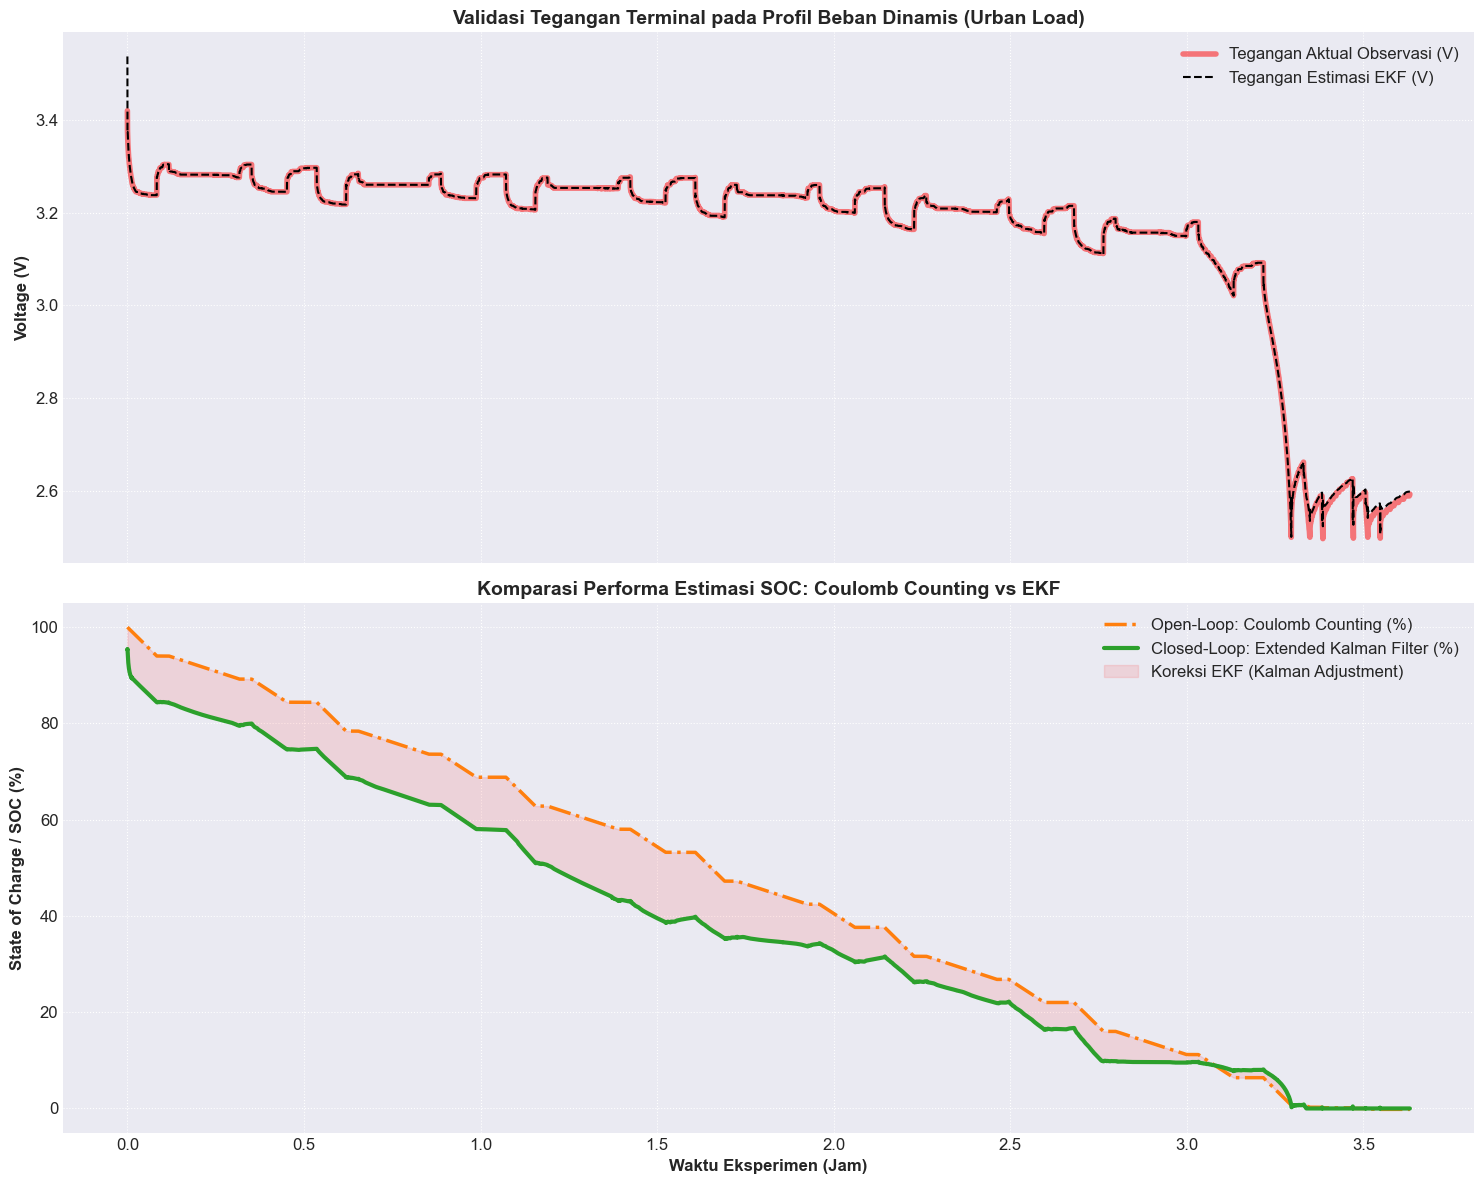

📊 RMSE Validasi Tegangan EKF: 0.0044 Volt


In [5]:
# =========================================================
# SIMULASI COULOMB COUNTING & EKF
# =========================================================
print("⏳ Menjalankan Simulasi EKF...")

# Coulomb Counting Terpisah
df['Coulomb_Discharged'] = (df['Cur(A)'] * df['dt']).cumsum()
df['SOC_CC'] = 1.0 - (df['Coulomb_Discharged'] / Q_Coulomb)

# Eksekusi EKF
ekf = EKF_BMS(Q_Coulomb=Q_Coulomb, f_ocv=f_OCV_LUT)
soc_ekf_history = []
v_pred_history = []

for i in range(len(df)):
    soc_est, v_pred = ekf.step(df['Cur(A)'].iloc[i], df['Vol(V)'].iloc[i], df['dt'].iloc[i])
    soc_ekf_history.append(soc_est)
    v_pred_history.append(v_pred)

df['SOC_EKF'] = soc_ekf_history
df['V_Pred'] = v_pred_history

print("✅ Simulasi Selesai!")

# =========================================================
# VISUALISASI HASIL VALIDASI
# =========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 12))
t_hrs = df['Time(S)'] / 3600.0

# 1. Plot Validasi Tegangan Model vs Observasi
ax1.plot(t_hrs, df['Vol(V)'], label='Tegangan Aktual Observasi (V)', color='red', alpha=0.5, linewidth=4)
ax1.plot(t_hrs, df['V_Pred'], label='Tegangan Estimasi EKF (V)', color='black', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Voltage (V)', fontweight='bold')
ax1.set_title('Validasi Tegangan Terminal pada Profil Beban Dinamis (Urban Load)', fontweight='bold', fontsize=14)
ax1.legend(); ax1.grid(True, linestyle=':')

# 2. Plot Validasi SOC CC vs EKF
ax2.plot(t_hrs, df['SOC_CC'] * 100, label='Open-Loop: Coulomb Counting (%)', color='tab:orange', linestyle='-.', linewidth=2.5)
ax2.plot(t_hrs, df['SOC_EKF'] * 100, label='Closed-Loop: Extended Kalman Filter (%)', color='tab:green', linewidth=3)
ax2.fill_between(t_hrs, df['SOC_CC'] * 100, df['SOC_EKF'] * 100, color='red', alpha=0.1, label='Koreksi EKF (Kalman Adjustment)')

ax2.set_xlabel('Waktu Eksperimen (Jam)', fontweight='bold')
ax2.set_ylabel('State of Charge / SOC (%)', fontweight='bold')
ax2.set_title('Komparasi Performa Estimasi SOC: Coulomb Counting vs EKF', fontweight='bold', fontsize=14)
ax2.legend(); ax2.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# Print Metrik RMSE Tegangan
rmse_v = np.sqrt(np.mean((df['Vol(V)'] - df['V_Pred'])**2))
print(f"📊 RMSE Validasi Tegangan EKF: {rmse_v:.4f} Volt")